# Telco Customer Churn Prediction

This notebook predicts which customers are likely to cancel (churn) their telecom
service, and identifies the factors that drive churn so the business can act on them.

**Pipeline:** load & clean data → EDA → encode features → train 5 classifiers
(with hyperparameter tuning and stratified cross-validation) → compare models →
inspect feature importance → tune the decision threshold → score every customer.

In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)  # silence sklearn's future-deprecation notices; nothing here is broken today

import numpy as np
import pandas as pd
from ydata_profiling import ProfileReport
import plotly.offline as po
import plotly.graph_objs as go
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

C:\Users\naman\AppData\Local\Temp\ipykernel_38744\1791653784.py:6: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [2]:
%matplotlib inline

## 1. Load & Inspect the Data

In [3]:
df = pd.read_csv("Tel_Customer_Churn_Dataset.csv")
df.shape

(7043, 21)

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


A quick automated profile of every column — distributions, missing values, "
   "cardinality, and correlations — before any cleaning. (`minimal=True` keeps this "
   "fast and keeps the notebook file small; set it to `False` for a deeper report.)

In [5]:
profile = ProfileReport(df, title="Customer Churn Report", minimal=True, progress_bar=False)
profile

100%|██████████| 21/21 [00:00<00:00, 22.72it/s]


## 2. Data Cleaning

Three fixes here:
1. Convert `Churn` from `Yes`/`No` text into `1`/`0` — using `.map()` on just this
   one column 
2. Collapse `"No internet/phone service"` into a plain `"No"` — it's a formatting
   artifact of how the source data was exported, not a genuinely different category.
3. Clean up `TotalCharges`, which loaded as text because a handful of brand-new
   customers (`tenure == 0`) have a blank value instead of `0`.

In [6]:
# Convert Yes/No churn labels to 1/0 — mapping only the Churn column, not the whole row
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [7]:
# Collapse "No internet service" down to "No" for the six internet add-on columns
cols = ['OnlineBackup', 'StreamingMovies', 'DeviceProtection', 'TechSupport', 'OnlineSecurity', 'StreamingTV']
for i in cols:
    df[i] = df[i].replace({'No internet service': 'No'})

# Same idea for the phone add-on column
df['MultipleLines'] = df['MultipleLines'].replace({'No phone service': 'No'})

In [8]:
# TotalCharges loaded as text because ~11 new customers have a blank value instead of 0 — clean it up
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)
df = df[df['TotalCharges'].notnull()]
df = df.reset_index()[df.columns]
df['TotalCharges'] = df['TotalCharges'].astype(float)
df.shape

(7032, 21)

## 3. Exploratory Data Analysis

In [9]:
df['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

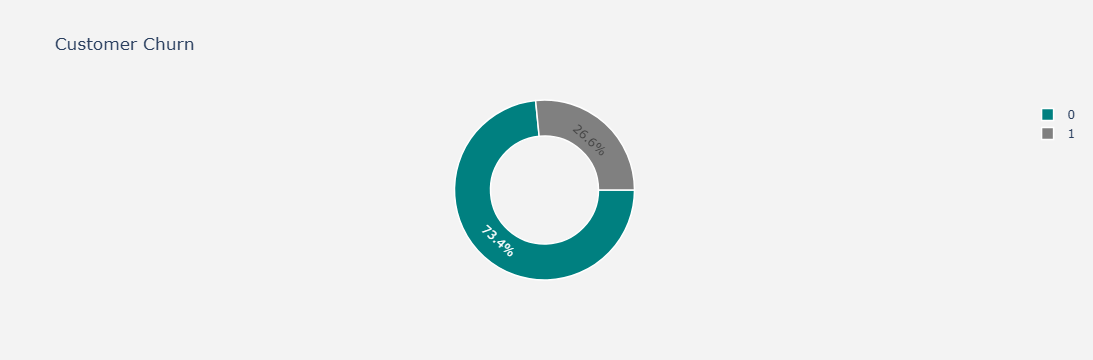

In [10]:
# Overall churn split
plot_by_churn_labels = df['Churn'].value_counts().keys().tolist()
plot_by_churn_values = df['Churn'].value_counts().values.tolist()

plot_data = [
    go.Pie(labels=plot_by_churn_labels, values=plot_by_churn_values,
           marker=dict(colors=['Teal', 'Grey'], line=dict(color='white', width=1.5)),
           rotation=90, hoverinfo='label+value+text', hole=.6)
]
plot_layout = go.Layout(dict(title='Customer Churn', plot_bgcolor='rgb(243,243,243)', paper_bgcolor='rgb(243,243,243)'))
fig = go.Figure(data=plot_data, layout=plot_layout)
po.iplot(fig)

**~26.6% of customers in this dataset have churned (1,869 of 7,032)** — a meaningful minority, but imbalanced enough that plain accuracy will be a misleading scoring metric later on.

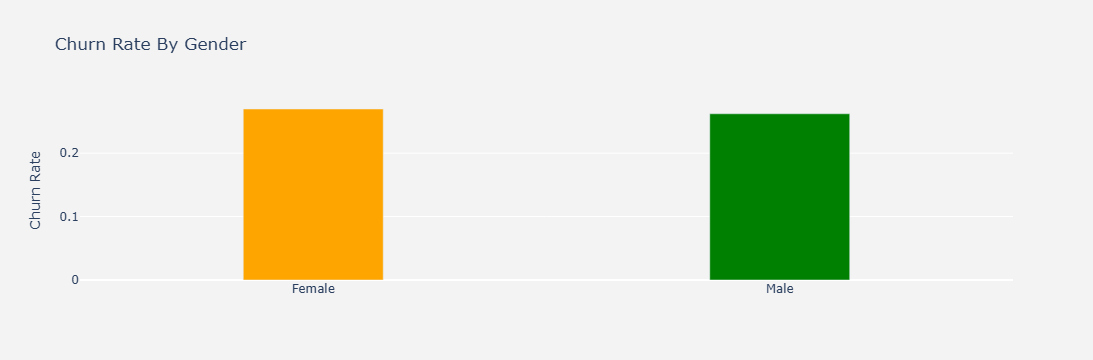

In [11]:
# Churn rate by gender
plot_by_gender = df.groupby('gender').Churn.mean().reset_index()
plot_data = [go.Bar(x=plot_by_gender['gender'], y=plot_by_gender['Churn'], width=[0.3, 0.3], marker=dict(color=['orange', 'green']))]
plot_layout = go.Layout(xaxis={'type': 'category'}, yaxis={'title': 'Churn Rate'}, title='Churn Rate By Gender',
                         plot_bgcolor='rgb(243,243,243)', paper_bgcolor='rgb(243,243,243)')
fig = go.Figure(data=plot_data, layout=plot_layout)
po.iplot(fig)

Female customers churn at 27.0% vs. 26.2% for male customers — essentially no difference. Gender turns out **not** to be a meaningful churn driver (confirmed later in the feature-importance section).

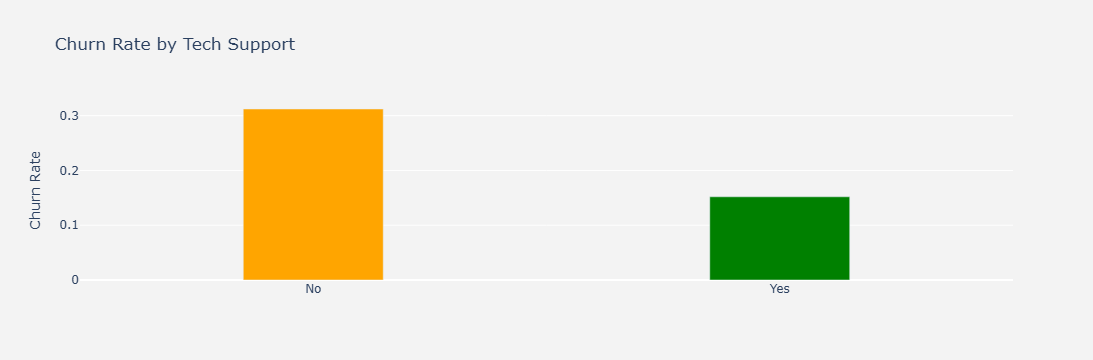

In [12]:
# Churn rate by tech support
plot_by_techsupport = df.groupby('TechSupport').Churn.mean().reset_index()
plot_data = [go.Bar(x=plot_by_techsupport['TechSupport'], y=plot_by_techsupport['Churn'], width=[0.3, 0.3, 0.3],
                     marker=dict(color=['orange', 'green', 'teal']))]
plot_layout = go.Layout(xaxis={"type": "category"}, yaxis={"title": "Churn Rate"}, title='Churn Rate by Tech Support',
                         plot_bgcolor='rgb(243,243,243)', paper_bgcolor='rgb(243,243,243)')
fig = go.Figure(data=plot_data, layout=plot_layout)
po.iplot(fig)

Customers **without** tech support churn about twice as often (31.2%) as those **with** it (15.2%). Tech support looks like a genuine retention lever, not just a correlation.

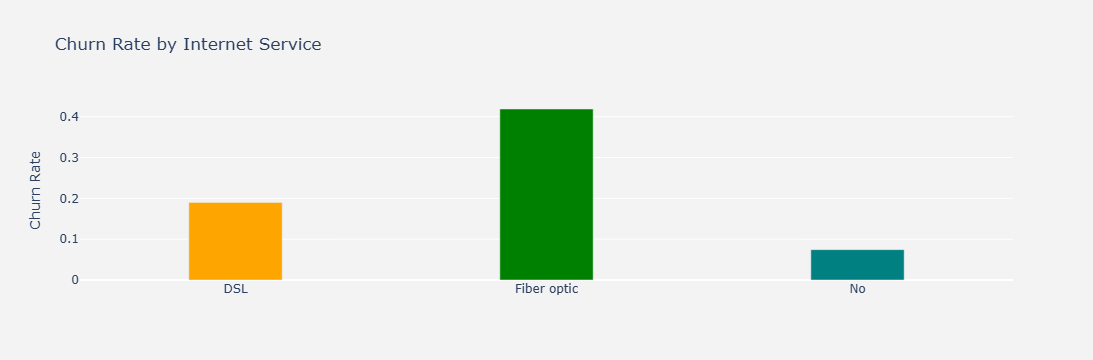

In [13]:
# Churn rate by internet service type
plot_by_internet_service = df.groupby('InternetService').Churn.mean().reset_index()
plot_data = [go.Bar(x=plot_by_internet_service['InternetService'], y=plot_by_internet_service['Churn'], width=[0.3, 0.3, 0.3],
                     marker=dict(color=['orange', 'green', 'teal']))]
plot_layout = go.Layout(xaxis={"type": "category"}, yaxis={"title": "Churn Rate"}, title='Churn Rate by Internet Service',
                         plot_bgcolor='rgb(243,243,243)', paper_bgcolor='rgb(243,243,243)')
fig = go.Figure(data=plot_data, layout=plot_layout)
po.iplot(fig)

**Fiber optic customers churn at 41.9%** — more than double DSL customers (19.0%), and nearly 6x customers with no internet service at all (7.4%). This is one of the strongest signals in the data, possibly reflecting pricing or service-quality complaints specific to the fiber product.

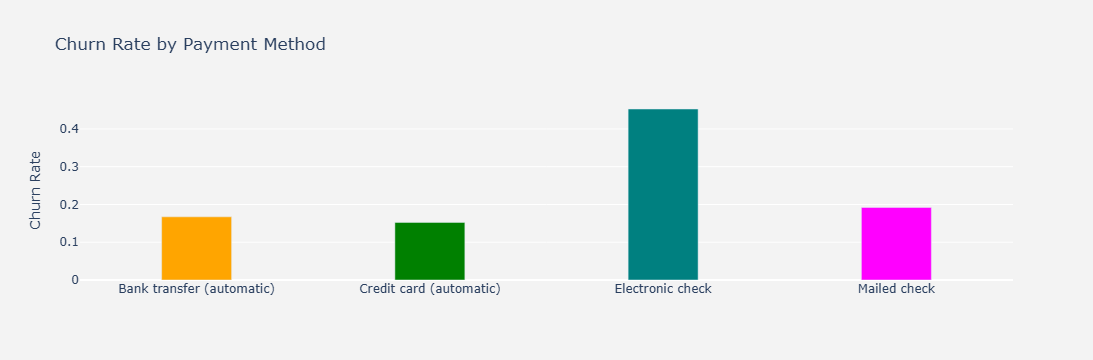

In [14]:
# Churn rate by payment method
plot_by_payment = df.groupby('PaymentMethod').Churn.mean().reset_index()
plot_data = [go.Bar(x=plot_by_payment['PaymentMethod'], y=plot_by_payment['Churn'], width=[0.3, 0.3, 0.3, 0.3],
                     marker=dict(color=['orange', 'green', 'teal', 'magenta']))]
plot_layout = go.Layout(xaxis={"type": "category"}, yaxis={"title": "Churn Rate"}, title='Churn Rate by Payment Method',
                         plot_bgcolor='rgb(243,243,243)', paper_bgcolor='rgb(243,243,243)')
fig = go.Figure(data=plot_data, layout=plot_layout)
po.iplot(fig)

**Electronic check payers churn at 45.3%** — roughly 3x the rate of customers on automatic bank transfer (16.7%) or credit card (15.3%). Manual, non-automatic payment looks strongly tied to churn, possibly because it also correlates with shorter, less-committed customer relationships.

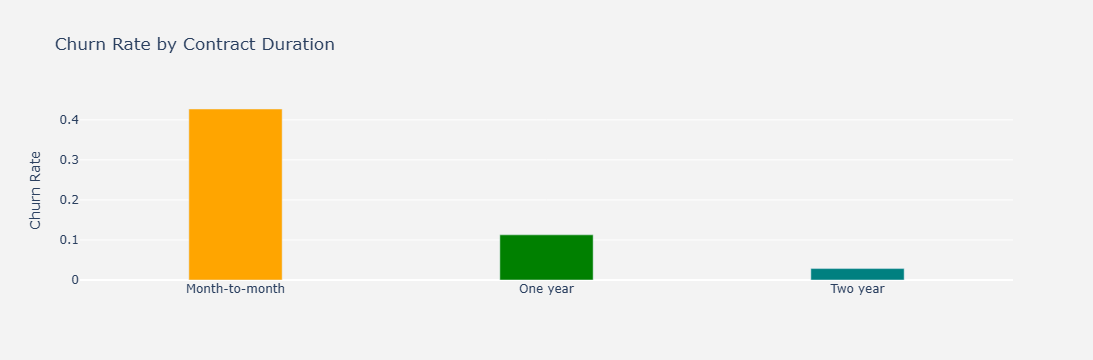

In [15]:
# Churn rate by contract length
plot_by_contract = df.groupby('Contract').Churn.mean().reset_index()
plot_data = [go.Bar(x=plot_by_contract['Contract'], y=plot_by_contract['Churn'], width=[0.3, 0.3, 0.3],
                     marker=dict(color=['orange', 'green', 'teal']))]
plot_layout = go.Layout(xaxis={"type": "category"}, yaxis={"title": "Churn Rate"}, title='Churn Rate by Contract Duration',
                         plot_bgcolor='rgb(243,243,243)', paper_bgcolor='rgb(243,243,243)')
fig = go.Figure(data=plot_data, layout=plot_layout)
po.iplot(fig)

**Contract length is the single biggest split in the data:** month-to-month customers churn at 42.7%, one-year contracts drop to 11.3%, and two-year contracts fall to just 2.8%. This holds up as the #1 predictor in the model later on too.

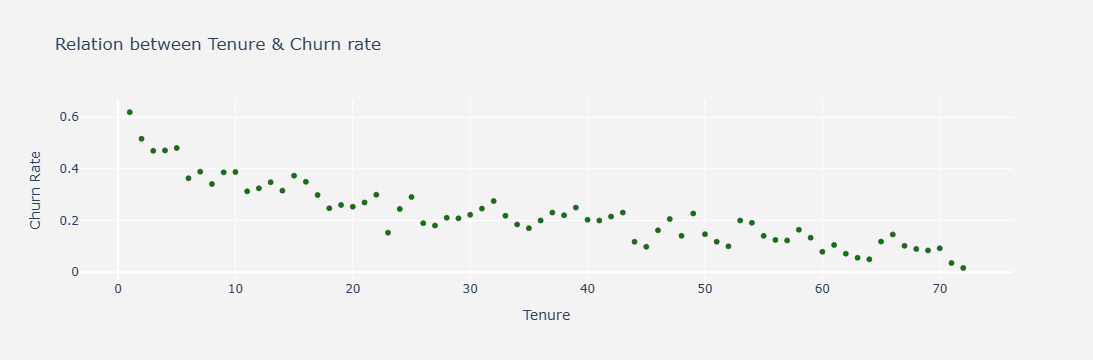

In [16]:
# Relationship between tenure and churn rate
plot_by_tenure = df.groupby('tenure').Churn.mean().reset_index()
plot_data = [go.Scatter(x=plot_by_tenure['tenure'], y=plot_by_tenure['Churn'], mode='markers', name='Low',
                         marker=dict(size=5, line=dict(width=0.8), color='green'))]
plot_layout = go.Layout(yaxis={'title': "Churn Rate"}, xaxis={'title': "Tenure"}, title='Relation between Tenure & Churn rate',
                         plot_bgcolor="rgb(243,243,243)", paper_bgcolor="rgb(243,243,243)")
fig = go.Figure(data=plot_data, layout=plot_layout)
po.iplot(fig)

In [17]:
df.groupby('Churn')['tenure'].mean().round(2)

Churn
0    37.65
1    17.98
Name: tenure, dtype: float64

Customers who stay average **37.7 months** of tenure; customers who churn average only **18.0 months**. Churn risk is clearly front-loaded — the first year or two of a customer relationship is the highest-risk window, which matters for *when* a retention program should intervene.

## 4. Feature Encoding

One-hot encode every categorical column (`drop_first=True` avoids the "dummy variable trap" — for a
column with *k* categories, only *k−1* dummy columns are needed since the last category is implied
when all others are 0).

In [18]:
df = pd.get_dummies(df, columns=['Contract', 'Dependents', 'DeviceProtection', 'gender',
                                  'InternetService', 'MultipleLines', 'OnlineBackup', 'OnlineSecurity',
                                  'PaperlessBilling', 'Partner', 'PaymentMethod', 'PhoneService',
                                  'StreamingMovies', 'StreamingTV', 'TechSupport'], drop_first=True)
df.head()

,customerID,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,Contract_One year,Contract_Two year,Dependents_Yes,DeviceProtection_Yes,...,OnlineSecurity_Yes,PaperlessBilling_Yes,Partner_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,PhoneService_Yes,StreamingMovies_Yes,StreamingTV_Yes,TechSupport_Yes
0,7590-VHVEG,0,1,29.85,29.85,0,False,False,False,False,...,False,True,True,False,True,False,False,False,False,False
1,5575-GNVDE,0,34,56.95,1889.50,0,True,False,False,True,...,True,False,False,False,False,True,True,False,False,False
2,3668-QPYBK,0,2,53.85,108.15,1,False,False,False,False,...,True,True,False,False,False,True,True,False,False,False
3,7795-CFOCW,0,45,42.30,1840.75,0,True,False,False,True,...,True,False,False,False,False,False,False,False,False,True
4,9237-HQITU,0,2,70.70,151.65,1,False,False,False,False,...,False,True,False,False,True,False,True,False,False,False


## 5. Train/Test Split

In [19]:
# Feature matrix and target — customerID is an identifier, not a predictive feature
y = df['Churn']
x = df.drop(['Churn', 'customerID'], axis=1)
x.shape

(7032, 23)

In [20]:
from sklearn.model_selection import train_test_split

# stratify=y keeps the ~73.5% / 26.5% churn split identical in both the train and test sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, stratify=y, random_state=50)
X_train.shape, X_test.shape

((4922, 23), (2110, 23))

## 6. Model Training

Each model below is wrapped in a `Pipeline` that scales `tenure`, `MonthlyCharges`, and `TotalCharges`
*inside* the pipeline.

This matters more than it looks: if you scale `X_train` once and then run cross-validation or
`GridSearchCV` on top of it, every internal validation fold was implicitly influenced by a scaler
that already "saw" that fold's data when computing the training mean/std — a subtle leak. Wrapping
the scaler inside the `Pipeline` means it gets refit from scratch on only the true training portion
of every single fold, automatically, everywhere it's used below.

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Scale only the 3 numeric columns; pass every already-binary dummy column through unchanged
preprocessor = ColumnTransformer(
    transformers=[('scale', StandardScaler(), numeric_cols)],
    remainder='passthrough'
)

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_validate, StratifiedKFold, cross_val_predict
from sklearn import metrics
from xgboost import XGBClassifier

# StratifiedKFold keeps the ~73.5/26.5 class ratio consistent in every fold, everywhere below
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=50)

In [32]:
# --- Logistic Regression, tuned over C and penalty ---
log_pipe = Pipeline([('preprocess', preprocessor),
                      ('clf', LogisticRegression(random_state=50, class_weight='balanced'))])

log_grid = {'clf__C': [0.01, 0.1, 1, 10, 100], 'clf__penalty': ['l1', 'l2'], 'clf__solver': ['liblinear']}

log_search = GridSearchCV(log_pipe, log_grid, scoring='f1', cv=5, n_jobs=-1)
log_search.fit(X_train, y_train)

print("Best params:", log_search.best_params_)
print("Best CV F1 score:", round(log_search.best_score_, 4))

logmodel = log_search.best_estimator_
y_pred = logmodel.predict(X_test)
logmodel_accuracy = round(metrics.accuracy_score(y_test, y_pred) * 100, 2)

Best params: {'clf__C': 1, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
Best CV F1 score: 0.6358


In [33]:
# --- K-Nearest Neighbors, tuned over n_neighbors / weights / distance metric ---
knn_pipe = Pipeline([('preprocess', preprocessor), ('clf', KNeighborsClassifier(metric='minkowski'))])

knn_grid = {'clf__n_neighbors': [3, 5, 7, 9, 11, 15, 21], 'clf__weights': ['uniform', 'distance'], 'clf__p': [1, 2]}

knn_search = GridSearchCV(knn_pipe, knn_grid, scoring='f1', cv=5, n_jobs=-1)
knn_search.fit(X_train, y_train)

print("Best params:", knn_search.best_params_)
print("Best CV F1 score:", round(knn_search.best_score_, 4))

knnmodel = knn_search.best_estimator_
knn_pred = knnmodel.predict(X_test)
knn_accuracy = round(metrics.accuracy_score(y_test, knn_pred) * 100, 2)

Best params: {'clf__n_neighbors': 15, 'clf__p': 1, 'clf__weights': 'uniform'}
Best CV F1 score: 0.594


In [34]:
# --- Decision Tree, tuned over depth / leaf size / split criterion ---
dt_pipe = Pipeline([('preprocess', preprocessor),
                     ('clf', DecisionTreeClassifier(random_state=50, class_weight='balanced'))])

dt_grid = {'clf__max_depth': [3, 5, 7, 10, 15, None], 'clf__min_samples_leaf': [1, 5, 10, 20],
           'clf__min_samples_split': [2, 10, 20], 'clf__criterion': ['gini', 'entropy']}

dt_search = GridSearchCV(dt_pipe, dt_grid, scoring='f1', cv=5, n_jobs=-1)
dt_search.fit(X_train, y_train)

print("Best params:", dt_search.best_params_)
print("Best CV F1 score:", round(dt_search.best_score_, 4))

dtmodel = dt_search.best_estimator_
dt_pred = dtmodel.predict(X_test)
dt_accuracy = round(metrics.accuracy_score(y_test, dt_pred) * 100, 2)

Best params: {'clf__criterion': 'gini', 'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2}
Best CV F1 score: 0.6233


In [35]:
# --- Random Forest ---
rfmodel = Pipeline([('preprocess', preprocessor),
                     ('clf', RandomForestClassifier(n_estimators=100, criterion='entropy',
                                                     random_state=50, class_weight='balanced'))])
rfmodel.fit(X_train, y_train)
rf_pred = rfmodel.predict(X_test)
rf_accuracy = round(metrics.accuracy_score(y_test, rf_pred) * 100, 2)

In [36]:
# --- XGBoost ---
# scale_pos_weight handles the ~73/27 imbalance (ratio of negatives to positives)
spw = (y_train == 0).sum() / (y_train == 1).sum()
xgbmodel = Pipeline([('preprocess', preprocessor),
                     ('clf', XGBClassifier(
                         n_estimators=300, max_depth=4, learning_rate=0.05,
                         subsample=0.9, colsample_bytree=0.9,
                         scale_pos_weight=spw, eval_metric='logloss',
                         random_state=50))])
xgbmodel.fit(X_train, y_train)
xgb_pred = xgbmodel.predict(X_test)
xgb_accuracy = round(metrics.accuracy_score(y_test, xgb_pred) * 100, 2)

## 7. Compare Models (Cross-Validated)

Ranking by accuracy alone would be misleading here — a model that predicted "No churn" for everyone
would still score ~73.5% accuracy. `Recall` (share of actual churners the model catches) and `F1`
(the balance between precision and recall) are the more honest metrics for this imbalanced problem.

In [37]:
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

models = {
    'Logistic Regression': logmodel,
    'K-Nearest Neighbors': knnmodel,
    'Decision Tree': dtmodel,
    'Random Forest': rfmodel,
    'XGBoost': xgbmodel
}

results = []
for name, model in models.items():
    cv_results = cross_validate(model, X_train, y_train, cv=cv5, scoring=scoring)
    results.append({
        'Model': name,
        'Accuracy': round(cv_results['test_accuracy'].mean() * 100, 2),
        'Precision': round(cv_results['test_precision'].mean() * 100, 2),
        'Recall': round(cv_results['test_recall'].mean() * 100, 2),
        'F1': round(cv_results['test_f1'].mean() * 100, 2),
        'ROC-AUC': round(cv_results['test_roc_auc'].mean() * 100, 2)
    })

Model_Comparison_df = pd.DataFrame(results).sort_values(by='F1', ascending=False).reset_index(drop=True)
Model_Comparison_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,75.29,52.30,80.66,63.45,84.89
1,XGBoost,76.29,53.85,76.60,63.23,84.31
2,Decision Tree,74.34,51.50,78.28,61.97,83.19
3,Random Forest,77.96,57.57,65.21,61.14,82.66
4,K-Nearest Neighbors,78.79,60.79,57.26,58.94,82.69


Logistic Regression comes out on top on F1 *and* ROC-AUC, so it's used as the "best model" from here
on. Worth noting the trade-off in the table: Random Forest and KNN post higher accuracy and precision,
but noticeably lower recall — they're more conservative about flagging churn, so they miss more actual
churners. If the business would rather cast a wider net and catch more at-risk customers (even at the
cost of more false alarms), Logistic Regression or XGBoost's higher recall is the better fit; if the goal is
fewer wasted retention offers, Random Forest's higher precision wins instead. There's no universally
"correct" choice here — it depends on which mistake costs the business more.

## 8. ROC and Precision-Recall Curves

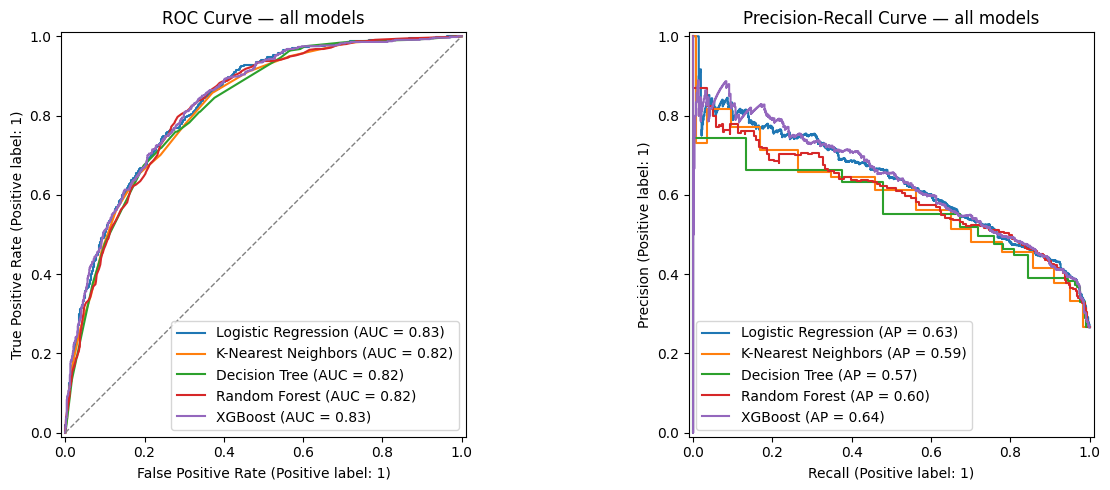

In [38]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=axes[0], name=name)
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=axes[1], name=name)

axes[0].set_title('ROC Curve — all models')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='grey', linewidth=1)
axes[1].set_title('Precision-Recall Curve — all models')
plt.tight_layout()
plt.show()

The ROC curves (left) sit close together — all 5 models separate churners from non-churners reasonably well overall. The precision-recall curves (right) spread out much more, which is expected: PR curves are far more sensitive to class imbalance than ROC curves, and are the more informative view for a problem where the positive class (churn) is the minority.

## 9. Detailed Evaluation of the Best Model

In [39]:
from sklearn.metrics import confusion_matrix, classification_report

# Pick whichever model actually topped the CV comparison, rather than assuming
best_model_name = Model_Comparison_df.iloc[0]['Model']
print(f"Best model by F1: {best_model_name}")

best_model = models[best_model_name]
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

conf_mat = confusion_matrix(y_test, y_pred)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

Best model by F1: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.70      0.79      1549
       Churn       0.49      0.79      0.60       561

    accuracy                           0.73      2110
   macro avg       0.70      0.74      0.70      2110
weighted avg       0.79      0.73      0.74      2110



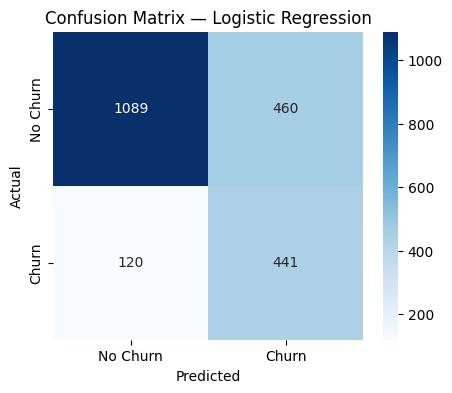

In [40]:
plt.figure(figsize=(5, 4))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix — {best_model_name}')
plt.show()

At the default 0.5 threshold, the model catches roughly 4 out of every 5 customers who actually churn (recall ≈ 79%) — but about half of everyone it *flags* as a churn risk turns out to stay (precision ≈ 49%). Whether that trade-off is acceptable depends on how expensive a false alarm (e.g. an unnecessary retention discount) is compared to a missed churner — the threshold section further down shows how to shift that balance.

## 10. What Drives Churn? (Feature Importance)

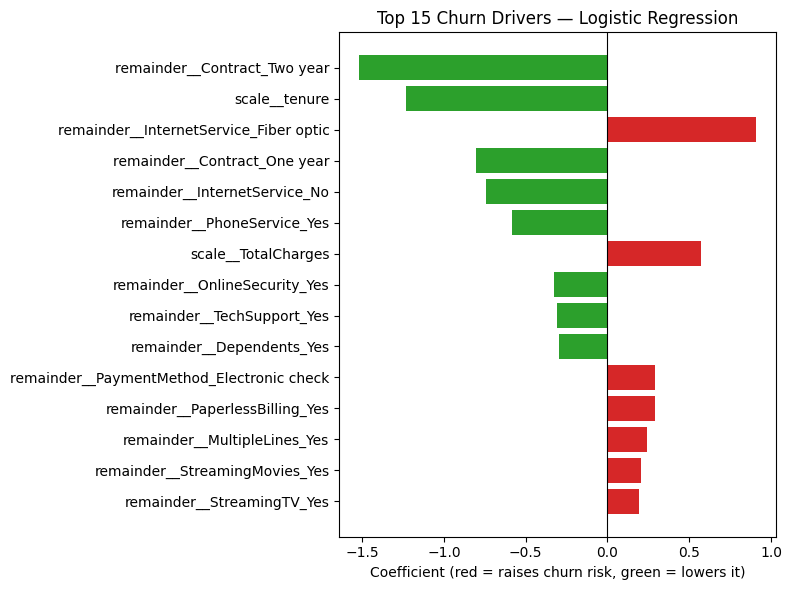

In [41]:
clf = best_model.named_steps['clf']
feat_names = best_model.named_steps['preprocess'].get_feature_names_out()

if hasattr(clf, 'coef_'):
    importance = clf.coef_[0]
elif hasattr(clf, 'feature_importances_'):
    importance = clf.feature_importances_

imp_df = pd.DataFrame({'feature': feat_names, 'importance': importance})
imp_df['abs_importance'] = imp_df['importance'].abs()
imp_df = imp_df.sort_values('abs_importance', ascending=False).head(15)

colors = ['#d62728' if v > 0 else '#2ca02c' for v in imp_df['importance']]
plt.figure(figsize=(8, 6))
plt.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color=colors[::-1])
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient (red = raises churn risk, green = lowers it)')
plt.title(f'Top 15 Churn Drivers — {best_model_name}')
plt.tight_layout()
plt.show()

The strongest churn drivers line up closely with what the EDA already suggested:

- **Contract length dominates.** Being on a two-year or one-year contract is the single strongest
  protection against churn — by far the biggest bars in the chart.
- **Tenure is the next strongest factor.** Every additional (scaled) unit of tenure meaningfully lowers
  churn probability, consistent with the "first year or two is the highest-risk window" pattern from the EDA.
- **Fiber optic internet raises churn risk** even after controlling for every other feature — this isn't
  just a side-effect of, say, fiber customers having shorter tenure; the effect holds on its own.
- **TotalCharges has a positive coefficient once tenure is already accounted for** — at a given tenure,
  higher-spending customers are somewhat more likely to churn, which is a candidate signal for a
  loyalty-pricing conversation.
- **Add-on services act as retention anchors**: having online security or tech support both push
  churn probability down, while paying by electronic check and paperless billing push it up slightly.
  Streaming add-ons (TV/movies) have small positive effects — worth a light touch, not a major focus.

## 11. Choosing a Decision Threshold

`.predict()` uses a 0.5 cutoff on the predicted probability by default. That's an arbitrary choice —
not something the business necessarily agreed to. Sweeping the threshold and watching precision and
recall move shows what other trade-offs are on the table.

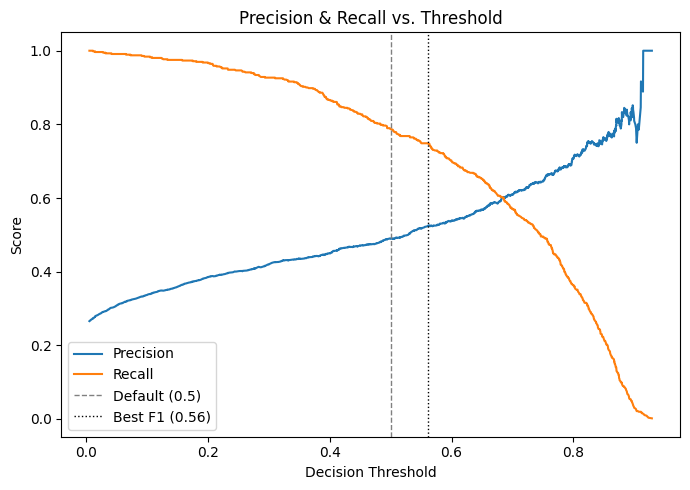

Default threshold (0.5):  precision=0.489, recall=0.786, f1=0.603
Best-F1 threshold (0.562): precision=0.525, recall=0.749, f1=0.617


In [42]:
from sklearn.metrics import precision_recall_curve, f1_score

probs = best_model.predict_proba(X_test)[:, 1]
prec, rec, thresholds = precision_recall_curve(y_test, probs)

f1_scores = 2 * prec * rec / (prec + rec + 1e-9)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]

plt.figure(figsize=(7, 5))
plt.plot(thresholds, prec[:-1], label='Precision')
plt.plot(thresholds, rec[:-1], label='Recall')
plt.axvline(0.5, color='grey', linestyle='--', linewidth=1, label='Default (0.5)')
plt.axvline(best_threshold, color='black', linestyle=':', linewidth=1, label=f'Best F1 ({best_threshold:.2f})')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Precision & Recall vs. Threshold')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Default threshold (0.5):  precision={prec[np.searchsorted(thresholds, 0.5)]:.3f}, "
      f"recall={rec[np.searchsorted(thresholds, 0.5)]:.3f}, f1={f1_score(y_test, (probs >= 0.5).astype(int)):.3f}")
print(f"Best-F1 threshold ({best_threshold:.3f}): precision={prec[best_idx]:.3f}, "
      f"recall={rec[best_idx]:.3f}, f1={f1_scores[best_idx]:.3f}")

Raising the threshold slightly to ~0.56 improves F1 from 0.60 to 0.62 — a modestly better balance
of precision and recall than the arbitrary 0.5 default. But F1 itself is just one more arbitrary choice
of what to optimize:

- **To catch more churners** (accept more false alarms), move the threshold *below* 0.5 — recall rises,
  precision falls further.
- **To reduce wasted retention spend** (fewer false alarms), move the threshold *above* 0.56 — precision
  rises, recall falls.

The right choice ultimately depends on the dollar cost of a missed churner vs. an unnecessary retention
offer, which is a business input this notebook can't supply on its own.

## 12. Score All Customers

To assign every customer a churn-risk score, `cross_val_predict` is used instead of just calling
`best_model.predict_proba()` on the full dataset. The difference matters: predicting on data a model was
trained on tends to look more confident than it should. `cross_val_predict` fits fresh copies of the
model across 5 folds so that every customer's probability comes from a model that never saw that
customer during training — every score below is a genuine out-of-sample estimate.

In [45]:
cv_oof = StratifiedKFold(n_splits=5, shuffle=True, random_state=50)
from sklearn.base import clone
oof_probs = cross_val_predict(clone(logmodel), x, y, cv=cv_oof, method='predict_proba', n_jobs=-1)[:, 1]

df['Probability_of_Churn'] = oof_probs
df[['customerID', 'Probability_of_Churn']].sort_values('Probability_of_Churn', ascending=False).head(10)

,customerID,Probability_of_Churn
5980,5567-WSELE,0.938556
1971,9497-QCMMS,0.936628
1405,7024-OHCCK,0.935676
6359,2720-WGKHP,0.935276
3743,4424-TKOPW,0.933787
994,1374-DMZUI,0.933675
3154,5150-ITWWB,0.932758
3374,5178-LMXOP,0.931934
4792,9300-AGZNL,0.931856
3340,2545-EBUPK,0.931767


## 13. Save the Model

In [44]:
joblib.dump(best_model, 'churn_model.pkl')
joblib.dump(list(x.columns), 'model_columns.pkl')
print(f"Saved {best_model_name} pipeline to churn_model.pkl")

Saved Logistic Regression pipeline to churn_model.pkl


## 14. Conclusion & Recommendations

**Model:** Logistic Regression was the best-performing of the 5 models tested (F1 ≈ 0.63, ROC-AUC ≈
0.85 on cross-validation), narrowly ahead of XGBoost and Decision Tree, and clearly ahead on recall
compared to Random Forest and KNN. On the held-out test set it correctly identifies about 79% of
customers who actually churn.

**What drives churn, in order of impact:**
1. **Contract type** — month-to-month customers churn at 15x the rate of two-year customers (42.7% vs. 2.9%).
2. **Tenure** — churn risk is heavily front-loaded; average tenure for churners is 18 months vs. 38 for retained customers.
3. **Internet service type** — fiber optic customers churn at more than double the rate of DSL customers.
4. **Payment method** — electronic check payers churn roughly 3x as often as customers on automatic payment.
5. **Support add-ons** — tech support and online security both meaningfully reduce churn risk; gender has no effect at all.

**Suggested next steps for the business:**
- Prioritize retention outreach for month-to-month, low-tenure, fiber optic customers — this segment
  concentrates the large majority of churn risk.
- Consider incentivizing a switch away from electronic check to automatic payment methods.
- Use the `Probability_of_Churn` score from Section 12 to rank the current customer base and target
  the highest-risk accounts first, and revisit the threshold in Section 11 once the business can supply
  a real cost estimate for a missed churner vs. an unnecessary retention offer.